# After a layoff, how likely is another? A survival analysis of repeat layoffs (v2)

**Version 1** (September 2026, SQL and Power BI) found that 17 of 164 companies (10.4%) with a layoff
between September 2025 and March 2026 cut again within six months, using a fixed six-month window so
that every company had the same time to repeat (decision 0007).

A fixed window is fair but wasteful: it discards every company whose first layoff came after March
2026, and its 3-, 6- and 9-month rows are computed on different companies. This notebook keeps v1's
definitions (14-day round rule, name merges) and asks:

1. Does the Python version reproduce the SQL exactly?
2. Should companies that **shut down** be in the denominator?
3. What does a **survival curve** using every company say, and how sure can we be?
4. Does the answer depend on the round rule?
5. Do bigger first cuts, industries or countries change the risk, or is the sample too small to tell?

The raw data stays private (decision 0002); every output below is an aggregate.

In [1]:
import json
import sqlite3
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy.optimize import minimize
from scipy.special import betaln
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import rounds as rd  # noqa: E402

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
R = {}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, WARM, GREY = "#1F3A5F", "#2A9D8F", "#C8553D", "#8A8A8A"


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")


def wilson(k, n):
    lo, hi = proportion_confint(k, n, method="wilson")
    return float(lo), float(hi)

## 1. Reproduce v1

In [2]:
d = rd.load(ROOT / "layoffs_global_12mo.csv")
e = rd.rounds(d, 14)
c = rd.companies(e)
R.update({"events": len(d), "companies": len(c), "repeat_companies": int((c["rounds"] >= 2).sum()),
          "missing_count": int(d["num_laid_off"].isna().sum()), "missing_pct": int(d["pct"].isna().sum())})
curve = []
for days in (90, 180, 270):
    el = c[c["first_round"] <= rd.DATA_END - pd.Timedelta(days=days)]
    k = int((el["days_to_second"] <= days).sum())
    curve.append({"months": days // 30, "eligible": len(el), "cut_again": k, "share": k / len(el)})
curve = pd.DataFrame(curve)
with sqlite3.connect(ROOT / "sql" / "layoffs.db") as con:
    sql_head = con.execute((ROOT / "sql" / "queries" / "04_repeat_rate.sql").read_text()).fetchone()
R["v1_curve"] = curve.to_dict(orient="records")
R["sql_headline"] = list(sql_head)
print(f"{len(d)} events, {len(c)} companies, {R['repeat_companies']} with two or more rounds")
print(curve.round(3).to_string(index=False))
print("SQL query 04:", sql_head)

442 events, 373 companies, 39 with two or more rounds
 months  eligible  cut_again  share
      3       276         11  0.040
      6       164         17  0.104
      9        90         22  0.244
SQL query 04: (164, 17, 10.4)


The Python rules reproduce query 04 and query 07 exactly: 17 of 164 within six months, 11 of 276 within
three, 22 of 90 within nine.

## 2. Companies that shut down cannot lay off again

In [3]:
el6 = c[c["first_round"] <= rd.DATA_END - pd.Timedelta(days=180)]
closed = el6["first_pct"] >= 1.0
k_all, n_all = int((el6["days_to_second"] <= 180).sum()), len(el6)
k_open, n_open = int((el6.loc[~closed, "days_to_second"] <= 180).sum()), int((~closed).sum())
R.update({"closures_in_v1_denominator": int(closed.sum()), "closures_cut_again": int((el6.loc[closed, "days_to_second"] <= 180).sum()),
          "headline_v1": k_all / n_all, "headline_v1_ci": wilson(k_all, n_all),
          "headline_open": k_open / n_open, "headline_open_k": k_open, "headline_open_n": n_open, "headline_open_ci": wilson(k_open, n_open)})
print(f"{closed.sum()} of v1's {n_all} companies laid off 100% of staff in their first round (they closed); "
      f"{R['closures_cut_again']} of them 'cut again'")
print(f"v1 headline {k_all}/{n_all} = {k_all / n_all:.1%}, 95% interval {R['headline_v1_ci'][0]:.1%} to {R['headline_v1_ci'][1]:.1%}")
print(f"among companies still operating: {k_open}/{n_open} = {k_open / n_open:.1%}, 95% interval "
      f"{R['headline_open_ci'][0]:.1%} to {R['headline_open_ci'][1]:.1%}")

12 of v1's 164 companies laid off 100% of staff in their first round (they closed); 0 of them 'cut again'
v1 headline 17/164 = 10.4%, 95% interval 6.6% to 16.0%
among companies still operating: 17/152 = 11.2%, 95% interval 7.1% to 17.2%


Twelve of v1's 164 companies laid off their entire workforce in the first round: they closed, so they
could never have a second round, and none did. Counting them as "did not cut again" pulls the rate down.
Among companies that were still operating, **17 of 152 (11.2%) cut again within six months**. The bigger
message is the interval: with 17 events the true rate could plausibly be anywhere from 7% to 17%, so
"about 1 in 10" is the right precision, and nothing finer.

## 3. One survival curve from every company

Each company is followed from its first round until either its second round (the event) or the end of
the data on 20 September 2026 (censored: we know only that no second round had happened *yet*). The
Kaplan-Meier estimator

$$\hat S(t) = \prod_{t_j \le t} \left(1 - \frac{d_j}{n_j}\right)$$

multiplies, at each day $t_j$ a second round happens, the share of the $n_j$ companies still being
followed that did *not* cut again. A company first seen in July 2026 contributes its two months of
evidence instead of being thrown away. $1 - \hat S(t)$ is the share expected to have cut again by day $t$;
Greenwood's formula gives its confidence band. Companies that closed in their first round are excluded
(they are not at risk).

330 companies still operating after their first round; 39 second rounds observed
by 3 months: 4.8% cut again (95% CI 2.9% to 8.0%); 246 companies still followed at that point
by 6 months: 10.2% cut again (95% CI 6.9% to 14.8%); 135 companies still followed at that point
by 9 months: 18.9% cut again (95% CI 13.4% to 26.3%); 60 companies still followed at that point


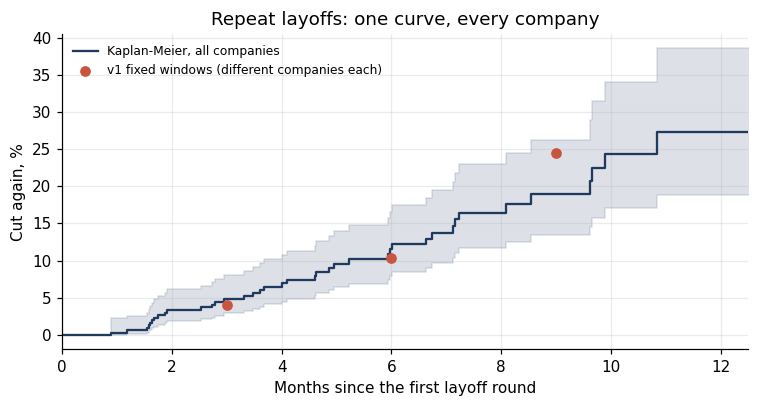

In [4]:
open_c = c[~(c["first_pct"] >= 1.0)].copy()
R["km_companies"], R["km_events"] = len(open_c), int(open_c["event"].sum())
kmf = KaplanMeierFitter().fit(open_c["duration"], open_c["event"])
km = {}
for days in (90, 180, 270):
    s = float(kmf.predict(days))
    ci = kmf.confidence_interval_survival_function_
    lo = float(1 - ci.loc[ci.index <= days].iloc[-1, 1])
    hi = float(1 - ci.loc[ci.index <= days].iloc[-1, 0])
    km[days] = {"cut_again": 1 - s, "lo": lo, "hi": hi, "at_risk": int((open_c["duration"] >= days).sum())}
R["km"] = km
print(f"{len(open_c)} companies still operating after their first round; {open_c['event'].sum()} second rounds observed")
for days, v in km.items():
    print(f"by {days // 30} months: {v['cut_again']:.1%} cut again (95% CI {v['lo']:.1%} to {v['hi']:.1%}); "
          f"{v['at_risk']} companies still followed at that point")

fig, ax = plt.subplots(figsize=(7, 3.8))
t = kmf.survival_function_.index
ax.step(t / 30.44, (1 - kmf.survival_function_.iloc[:, 0]) * 100, where="post", color=INK, label="Kaplan-Meier, all companies")
band = kmf.confidence_interval_survival_function_
ax.fill_between(band.index / 30.44, (1 - band.iloc[:, 1]) * 100, (1 - band.iloc[:, 0]) * 100, step="post", color=INK, alpha=0.15)
ax.scatter(curve["months"], curve["share"] * 100, color=WARM, zorder=5, label="v1 fixed windows (different companies each)")
ax.set(xlabel="Months since the first layoff round", ylabel="Cut again, %", title="Repeat layoffs: one curve, every company",
       xlim=(0, 12.5))
ax.legend(frameon=False, fontsize=8, loc="upper left")
save(fig, "km_repeat.png")

The survival curve uses all 330 companies that kept operating, including the 178 v1 had to set aside:
**10.2% are expected to cut again within six months** (95% interval 6.9% to 14.8%), close to v1's
fixed-window figure, so the headline stands. The nine-month figure does not: v1's 24.4% came from the
90 earliest companies only, while the curve, built from every company, gives 18.9% (13.4% to 26.3%).
The fixed windows' rise from 4% to 24% partly reflected *which* companies could be followed that long.

### When does a second round come?

The hazard: of the companies still without a second round at the start of month m, the share that
cut again during it.

In [5]:
lt = []
for m in range(12):
    a, b = m * 30.44, (m + 1) * 30.44
    at = open_c[open_c["duration"] > a]
    ev = int(((at["event"] == 1) & (at["duration"] <= b)).sum())
    lt.append({"month": m + 1, "at_risk": len(at), "second_rounds": ev, "hazard": ev / len(at) if len(at) else np.nan})
lt = pd.DataFrame(lt)
print(lt.round(3).to_string(index=False))
R["monthly_hazard"] = lt.round(4).to_dict(orient="records")

 month  at_risk  second_rounds  hazard
     1      329              1   0.003
     2      311              9   0.029
     3      278              4   0.014
     4      242              4   0.017
     5      207              6   0.029
     6      163              3   0.018
     7      130              3   0.023
     8       99              3   0.030
     9       75              2   0.027
    10       59              3   0.051
    11       39              1   0.026
    12       21              0   0.000


Month 1 is near zero by construction (events within 14 days are merged into one round). After that,
roughly 1.5% to 3% of companies that have not yet cut again do so each month, with no sign of the risk
fading through month 10. For an employee the practical reading is that "we got through the first few
months" is not much reassurance: the monthly risk later in the year is about the same as early on.

## 4. Does the answer depend on the round rule?

In [6]:
sens = []
for md in (7, 14, 30, 60, 90):
    cc = rd.companies(rd.rounds(d, md))
    oc = cc[~(cc["first_pct"] >= 1.0)]
    k6 = KaplanMeierFitter().fit(oc["duration"], oc["event"])
    el = oc[oc["first_round"] <= rd.DATA_END - pd.Timedelta(days=180)]
    sens.append({"merge_days": md, "companies_with_2plus_rounds": int((cc["rounds"] >= 2).sum()),
                 "fixed_window_6m": float((el["days_to_second"] <= 180).mean()), "km_6m": float(1 - k6.predict(180))})
sens = pd.DataFrame(sens)
print(sens.round(3).to_string(index=False))
R["merge_sensitivity"] = sens.round(4).to_dict(orient="records")

 merge_days  companies_with_2plus_rounds  fixed_window_6m  km_6m
          7                           39            0.112  0.102
         14                           39            0.112  0.102
         30                           38            0.112  0.099
         60                           32            0.086  0.075
         90                           28            0.072  0.059


At 7, 14 or 30 days the six-month estimate barely moves (10.2%, 10.2%, 9.9%); only 60 and 90 days pull it
down, by merging genuine second rounds into first ones. This confirms decision 0006 with a curve that
uses every company.

## 5. Who is more likely to cut again?

With fewer than 40 second rounds, any comparison is fragile; the point of this section is to show how
fragile, with intervals, rather than to rank anyone.

### Size of the first cut

   first_cut  companies  second_rounds  km_6m
   under 10%         68             12  0.163
      10-25%         68              5  0.060
      25-99%         35              1  0.040
not reported        159             21  0.104
log-rank test across groups: p = 0.084


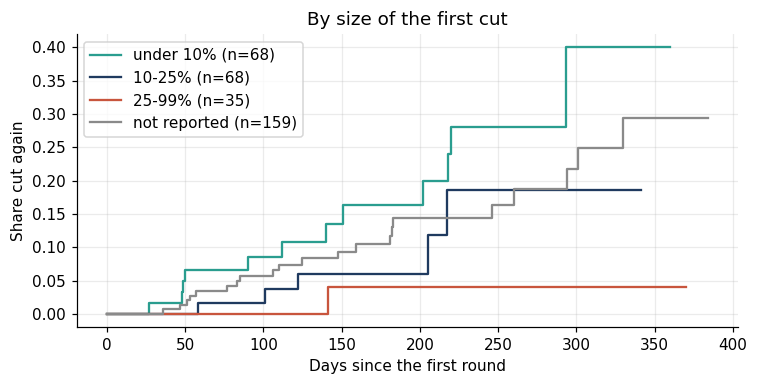

In [7]:
open_c["first_size"] = pd.cut(open_c["first_pct"], [0, 0.10, 0.25, 0.999], labels=["under 10%", "10-25%", "25-99%"])
open_c["first_size"] = open_c["first_size"].cat.add_categories("not reported").fillna("not reported")
size_tab = []
fig, ax = plt.subplots(figsize=(7, 3.6))
for (g, sub), col in zip(open_c.groupby("first_size", observed=True), (ACCENT, INK, WARM, GREY)):
    k = KaplanMeierFitter().fit(sub["duration"], sub["event"], label=f"{g} (n={len(sub)})")
    k.plot_cumulative_density(ax=ax, ci_show=False, color=col)
    size_tab.append({"first_cut": str(g), "companies": len(sub), "second_rounds": int(sub["event"].sum()),
                     "km_6m": float(1 - k.predict(180))})
size_tab = pd.DataFrame(size_tab)
lr_size = multivariate_logrank_test(open_c["duration"], open_c["first_size"], open_c["event"])
R["by_first_cut"] = size_tab.round(4).to_dict(orient="records")
R["first_cut_logrank_p"] = float(lr_size.p_value)
ax.set(xlabel="Days since the first round", ylabel="Share cut again", title="By size of the first cut")
save(fig, "km_by_first_cut.png")
print(size_tab.round(3).to_string(index=False))
print(f"log-rank test across groups: p = {lr_size.p_value:.3f}")

Companies whose first cut was **small** (under 10% of staff) were the most likely to cut again: 16.3%
within six months, against 6.0% after a 10-25% cut and 4.0% after a deeper one. That fits a familiar
pattern, trimming in stages instead of one decisive cut, but the evidence is weak (log-rank p = 0.08, 18
second rounds across the three known-size groups) and the cut size is unknown for 159 companies. It is
a hypothesis for the next year of data, not a finding.

### A proportional-hazards model

Cox regression estimates how each characteristic multiplies the monthly chance of a second round,
holding the others fixed: log of the first cut's headcount (when reported), whether the percentage was
reported, and whether the company is US-based.

In [8]:
cox = open_c.assign(log_count=np.log1p(open_c["first_count"]), count_known=open_c["first_count"].notna().astype(int),
                    us=(open_c["country"] == "United States").astype(int))
cox["log_count"] = cox["log_count"].fillna(cox["log_count"].median())
cph = CoxPHFitter().fit(cox[["duration", "event", "log_count", "count_known", "us"]], "duration", "event")
summ = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
print(summ.round(3).to_string())
R["cox"] = summ.round(4).to_dict(orient="index")

             exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                              
log_count        1.041                0.794                1.365  0.771
count_known      1.594                0.698                3.641  0.269
us               1.244                0.654                2.364  0.506


None of the three characteristics moves the risk detectably: every hazard ratio's interval comfortably
spans 1. With 39 events this is what an honest model looks like; claiming that US companies or bigger
layoffs are riskier would be reading noise.

### Industries, shrunk toward the overall rate

v1 reported Retail 3 of 10 and Finance 0 of 20 and warned that such groups are small. A beta-binomial
model makes the warning quantitative: each industry's true six-month rate is drawn from a common Beta
distribution fitted to all industries, and each industry's estimate is pulled toward the overall rate
in proportion to how few companies it has.

In [9]:
el_open = el6[~closed].copy()
ind = el_open.groupby("industry").agg(n=("days_to_second", "size"), k=("days_to_second", lambda x: int((x <= 180).sum())))


def bb_negll(params, k, n):
    a, b = np.exp(params)
    return -np.sum(betaln(k + a, n - k + b) - betaln(a, b))


res = minimize(bb_negll, np.log([1.0, 8.0]), args=(ind["k"].to_numpy(), ind["n"].to_numpy()), method="Nelder-Mead")
a, b = np.exp(res.x)
ind["raw"] = ind["k"] / ind["n"]
ind["shrunk"] = (ind["k"] + a) / (ind["n"] + a + b)
R["bb_prior_mean"], R["bb_prior_strength"] = float(a / (a + b)), float(a + b)
show = ind[ind["n"] >= 8].sort_values("raw", ascending=False)
print(f"prior: mean {a / (a + b):.1%}, worth {a + b:.1f} companies of evidence")
print(show.round(3).to_string())
R["industries"] = show.round(4).to_dict(orient="index")

prior: mean 10.7%, worth 32.7 companies of evidence
                 n  k    raw  shrunk
industry                            
Retail           9  3  0.333   0.156
Transportation   8  2  0.250   0.136
Consumer        25  5  0.200   0.148
Other           16  1  0.062   0.093
Finance         18  0  0.000   0.069


The fitted prior says industries' true rates cluster around 10.7%, and that an industry's own record
should count for about as much as 33 companies of prior evidence. Retail's raw 3 of 9 (33%) therefore
becomes 15.6%, and Finance's 0 of 18 becomes 6.9%. v1's caution was right: the industry differences are
mostly sample size.

## 6. Conclusions and limits

| v1 | v2 |
|---|---|
| 17 of 164 (10.4%) cut again within 6 months | 12 of the 164 had closed; among companies still operating, 17 of 152 (11.2%, 95% interval 7.1% to 17.2%) |
| 3, 6 and 9 months: 4.0%, 10.4%, 24.4% (different companies each) | One survival curve from all 330 operating companies: 4.8%, 10.2%, 18.9% |
| 14-day round rule | Confirmed: the six-month estimate is the same at 7, 14 and 30 days |
| Industry rates descriptive only | Quantified: shrunk toward 10.7%, Retail 15.6%, Finance 6.9% |
| | New: the monthly risk of a second round does not fade through month 10; small first cuts may repeat more (p = 0.08) |

**Limits.** One year of announcements, leaning towards tech and newsworthy companies; a company's
"first" round here may not be its first ever (layoffs before September 2025 are not in the data);
headcount is missing for a third of events and percentage for nearly half; the analysis describes
announcements, not outcomes for the people affected.

In [10]:
(ROOT / "results").mkdir(exist_ok=True)
(ROOT / "results" / "metrics.json").write_text(json.dumps(R, indent=1, default=float))
print(json.dumps({k: v for k, v in R.items() if not isinstance(v, (dict, list))}, indent=1, default=float))

{
 "events": 442,
 "companies": 373,
 "repeat_companies": 39,
 "missing_count": 150,
 "missing_pct": 204,
 "closures_in_v1_denominator": 12,
 "closures_cut_again": 0,
 "headline_v1": 0.10365853658536585,
 "headline_v1_ci": [
  0.06573150818853768,
  0.1597280361134476
 ],
 "headline_open": 0.1118421052631579,
 "headline_open_k": 17,
 "headline_open_n": 152,
 "headline_open_ci": [
  0.0710107577303746,
  0.17180947192515766
 ],
 "km_companies": 330,
 "km_events": 39,
 "first_cut_logrank_p": 0.08380852555132391,
 "bb_prior_mean": 0.10746246480220828,
 "bb_prior_strength": 32.65520910254676
}
